<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Poster_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

# type hints
from typing import List, Tuple
from collections import defaultdict
from google.colab import drive

from skimage.filters import (
    threshold_otsu,
    threshold_multiotsu
)

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
  try:
    plt.imshow(image, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
  except Exception as e:
    return ValueError(f"Unknown error occured: {e}")

def show_multi_threshold_histogram(gray, thresholds, bins=256, title="Multi-Level Threshold Histogram"):
    plt.figure(figsize=(10, 5))
    plt.hist(gray.ravel(), bins=bins, range=(0, 256), color="gray", alpha=0.7)

    if not(thresholds == None):
        # Sort thresholds to ensure labels are placed correctly
        thresholds = sorted(thresholds)

        # Add the "boundary" points for labeling (0 and 255)
        all_bounds = [0] + thresholds + [256]

        for i, t in enumerate(thresholds):
            # Draw the vertical line
            plt.axvline(t, color='red', linestyle='--', linewidth=2, label=f'Threshold {i+1}: {t}')

        # Label the ranges/regions
        for i in range(len(all_bounds) - 1):
            midpoint = (all_bounds[i] + all_bounds[i+1]) / 2
            plt.text(midpoint, plt.gca().get_ylim()[1] * 0.9, f"Region {i+1}",
                     horizontalalignment='center', fontweight='bold', color='blue')

        plt.title(title)
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()
    else:
        plt.title(title)
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.show()

# helper function to convert to graytone or vice versa
M = 255.0
epsilon = 1e-6

def grayToneCvt(g: np.ndarray) -> np.ndarray:
    g = g.astype(np.float32)
    return np.clip(M - g, 0, M - epsilon)

def grayLevelCvt(tone):
    return np.clip(M - tone, 0, M - epsilon)

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def loadImageFromDrive(filename: str, driveFolder: str = 'CSC475/Homework7', color="RGB") -> np.ndarray:
  """
  Loads an image from Google Drive into a NumPy array.
  """
  try:
    filePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"

    loadedImgBgr = cv.imread(filePath)

    print(f'Image successfully loaded from: {filePath}')
    if color == "gray":
      return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2GRAY)

    if color == "RGB":
      return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2RGB)

    if color == "BGR":
      return loadedImgBgr

  except Exception as e:
    print(f'Error loading image from Drive: {e}')
    return None

In [ ]:
filename = "/image 10.jpg"
marsImage = loadImageFromDrive(filename, color="RGB")
grayMarsImage = loadImageFromDrive(filename, color="gray")

show(marsImage, cmap="gray", title="Original Image")

NameError: name 'loadImageFromDrive' is not defined

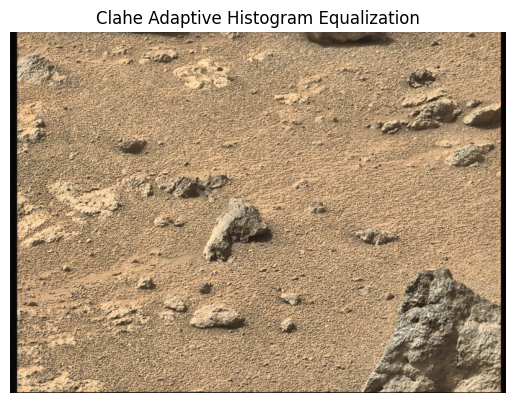

In [ ]:
def clahe(image: np.ndarray, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV)
    h, s, v = cv.split(hsv)

    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    v_clahe = clahe.apply(v)

    hsv_clahe = cv.merge([h, s, v_clahe])
    return cv.cvtColor(hsv_clahe, cv.COLOR_HSV2RGB)

claheMarsImg = clahe(marsImage)
show(clahe(marsImage), cmap="gray", title="Clahe Adaptive Histogram Equalization")

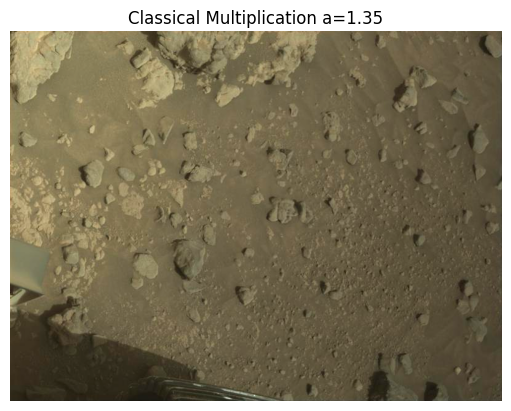

In [ ]:
def multiply_c(image: np.ndarray, c: float) -> np.ndarray:
  return np.clip(image * c, 0, 255).astype(np.uint8)

a = 1.35
classicalMultiplicationImg = multiply_c(marsImage, a)
show(classicalMultiplicationImg, cmap="gray", title=f"Classical Multiplication a=1.35")

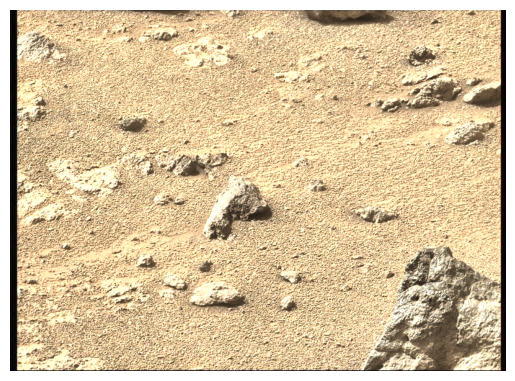

In [ ]:
def sCurveStretchGray(image: np.ndarray, alpha: float = 10.0, beta: float = 0.5) -> np.ndarray:
    """
    Sigmoid (S-curve) contrast stretch.

    alpha: controls steepness (contrast)
    beta : midpoint (in [0,1])
    """
    img = image.astype(np.float32) / 255.0

    # Sigmoid function
    s = 1.0 / (1.0 + np.exp(-alpha * (img - beta)))

    # Normalize so output stays in [0,1]
    s_min = 1.0 / (1.0 + np.exp(alpha * beta))
    s_max = 1.0 / (1.0 + np.exp(-alpha * (1 - beta)))

    s_norm = (s - s_min) / (s_max - s_min)

    return np.clip(s_norm * 255.0, 0, 255).astype(np.uint8)

def sCurveStretch(image: np.ndarray, alpha: float = 10.0, beta: float = 0.5) -> np.ndarray:
    """
    Apply S-curve contrast stretch to the V channel of an RGB image.
    """
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV).astype(np.float32)

    v = hsv[:, :, 2].astype(np.uint8)
    v_stretched = sCurveStretchGray(v, alpha=alpha, beta=beta)

    hsv[:, :, 2] = v_stretched.astype(np.float32)
    hsv = np.clip(hsv, 0, 255).astype(np.uint8)

    return cv.cvtColor(hsv, cv.COLOR_HSV2RGB)

alpha = 1.25
beta = 0.75
show(sCurveStretch(classicalMultiplicationImg, alpha=alpha, beta=beta), cmap="gray")

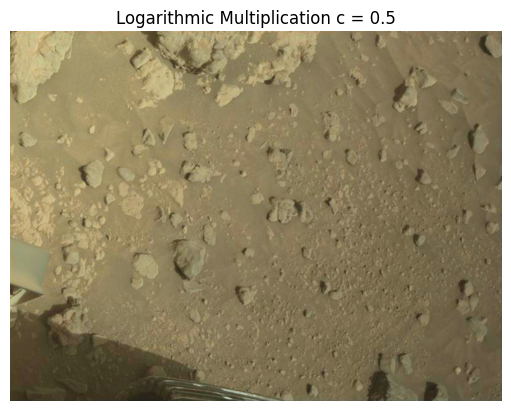

In [ ]:
def scalarLipMult(a: np.ndarray, c: float) -> np.ndarray:
    a = a.astype(np.float32)
    return M - M * ((1 - a / M) ** c)

def applyLipMultHSV(image: np.ndarray, c: float = 0.5) -> np.ndarray:
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV).astype(np.float32)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    v_lip = scalarLipMult(v, c)
    v_lip = np.clip(v_lip, 0, 255)

    hsv_result = np.stack((h, s, v_lip), axis=2).astype(np.uint8)
    rgb_result = cv.cvtColor(hsv_result, cv.COLOR_HSV2RGB)

    return rgb_result

def SapplyLipMultHSV(image: np.ndarray, c: float = 0.5) -> np.ndarray:
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV).astype(np.float32)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    s_lip = scalarLipMult(s, c)
    s_lip = np.clip(s_lip, 0, 255)

    hsv_result = np.stack((h, s_lip, v), axis=2).astype(np.uint8)
    rgb_result = cv.cvtColor(hsv_result, cv.COLOR_HSV2RGB)

    return rgb_result

constant = 2

v_scalar_mult = applyLipMultHSV(marsImage, constant)
show(v_scalar_mult, title=f"Logarithmic Multiplication c = 0.5")

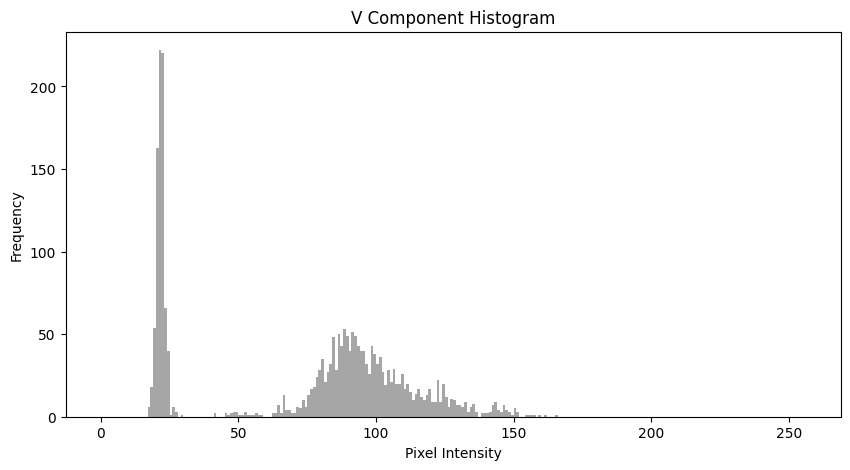

In [ ]:
show_multi_threshold_histogram(cv.cvtColor(marsImage, cv.COLOR_RGB2HSV)[2], thresholds=None, title="V Component Histogram")

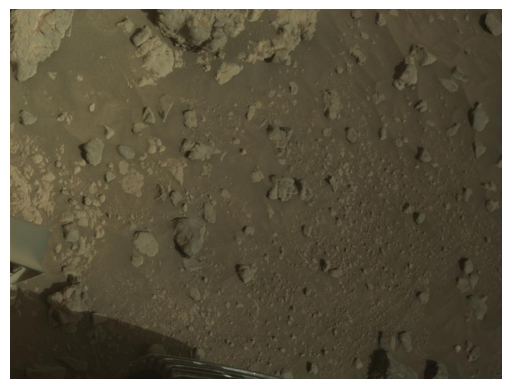

In [ ]:
show(marsImage, cmap="gray")

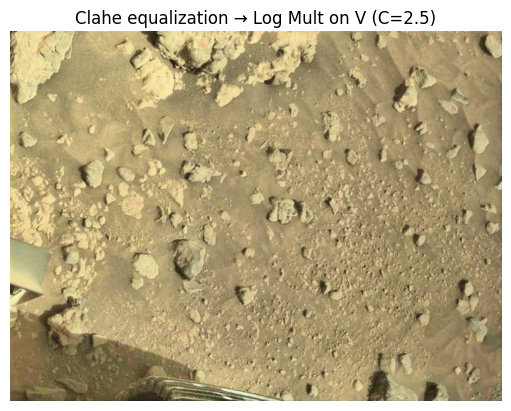

In [ ]:
constant = 2.5
logClahe = applyLipMultHSV(claheMarsImg, constant)

show(logClahe, cmap="gray", title=f"Clahe equalization → Log Mult on V (C={constant})")

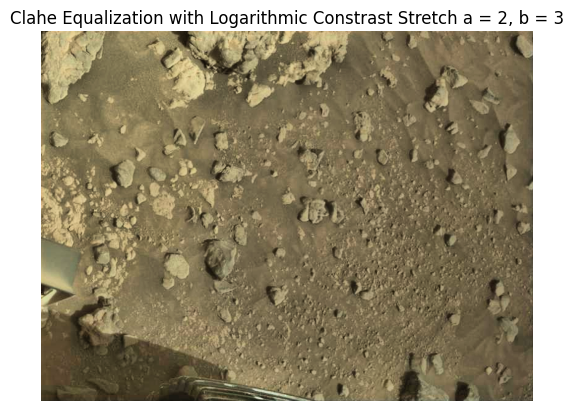

In [ ]:
def logarithmicStretchGray(image: np.ndarray, alpha: float = 100, beta: float = 100) -> np.ndarray:
    """
    Logarithmic contrast stretch with:
      alpha = enhancement strength
      beta  = pivot point in [0, 1]

    image: grayscale uint8 image
    returns: uint8 grayscale image
    """
    img = image.astype(np.float32) / 255.0
    beta = np.clip(beta, 1e-6, 1 - 1e-6)

    out = np.zeros_like(img, dtype=np.float32)

    # Lower side: map [0, beta] -> [0, beta]
    lower = img <= beta
    if np.any(lower):
        x = img[lower] / beta
        out[lower] = beta * (np.log1p(alpha * x) / np.log1p(alpha))

    # Upper side: map [beta, 1] -> [beta, 1]
    upper = img > beta
    if np.any(upper):
        x = (img[upper] - beta) / (1.0 - beta)
        out[upper] = beta + (1.0 - beta) * (np.log1p(alpha * x) / np.log1p(alpha))

    return np.clip(out * 255.0, 0, 255).astype(np.uint8)

def logarithmicStretch(image: np.ndarray, alpha: float = 5, beta: float = 9) -> np.ndarray:
    """
    Apply logarithmic contrast stretch to the V channel of an RGB image.

    alpha: enhancement strength
    beta : pivot point in [0, 1]
    """
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV).astype(np.float32)

    v = hsv[:, :, 2].astype(np.uint8)
    v_stretched = logarithmicStretchGray(v, alpha=alpha, beta=beta)

    hsv[:, :, 2] = v_stretched.astype(np.float32)
    hsv = np.clip(hsv, 0, 255).astype(np.uint8)

    return cv.cvtColor(hsv, cv.COLOR_HSV2RGB)

alpha = 2
beta = 3
newImg = logarithmicStretch(claheMarsImg, alpha=alpha, beta=beta)
lipMult = applyLipMultHSV(claheMarsImg, c=1.5)
show(lipMult, cmap="gray", title=f"Clahe Equalization with Logarithmic Constrast Stretch a = {alpha}, b = {beta}")

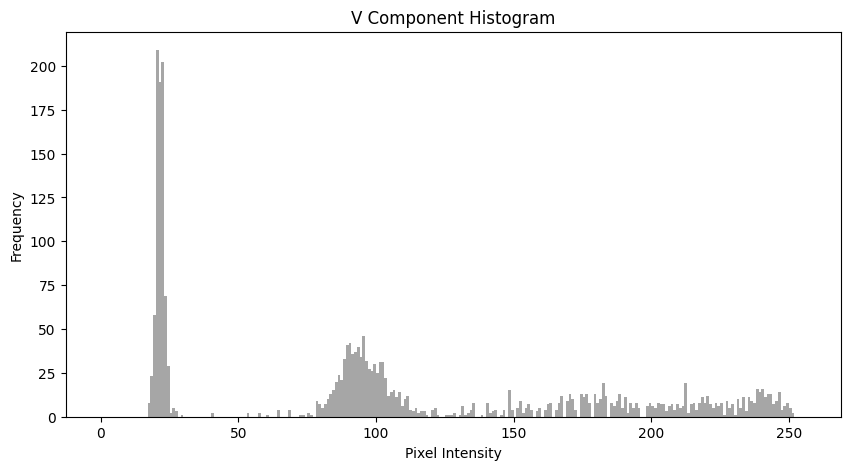

In [ ]:
show_multi_threshold_histogram(cv.cvtColor(logClahe, cv.COLOR_RGB2HSV)[2], thresholds=None, title="V Component Histogram")

In [ ]:
def otsu_threshold(gray):
    T = threshold_otsu(gray)
    binary = (gray > T).astype(np.uint8) * 255
    return T, binary

def multi_otsu_threshold(gray, classes=3):
    thresholds = threshold_multiotsu(gray, classes=classes)
    regions = np.digitize(gray, bins=thresholds)

    # scale to 0..255 for display
    if classes == 3:
        display = (regions * 127).astype(np.uint8)   # 0,127,254
    else:
        display = (regions * (255 // (classes - 1))).astype(np.uint8)

    return thresholds, regions, display

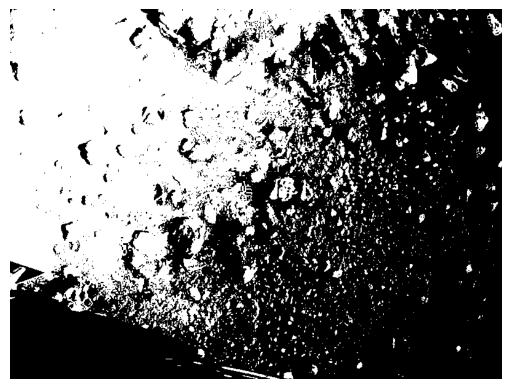

In [ ]:
threshold, binary = otsu_threshold(grayMarsImage)
show(binary, cmap="gray")